In [1]:
%pip install -e "C:\Users\jaspe\Documents\CLS\Thesis\research_core"

Obtaining file:///C:/Users/jaspe/Documents/CLS/Thesis/research_core
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build editable did not run successfully.
  │ exit code: 1
  ╰─> [8 lines of output]
      running egg_info
      creating research_core.egg-info
      writing research_core.egg-info\PKG-INFO
      writing dependency_links to research_core.egg-info\dependency_links.txt
      writing requirements to research_core.egg-info\requires.txt
      writing top-level names to research_core.egg-info\top_level.txt
      writing manifest file 'research_core.egg-info\SOURCES.txt'
      error: package directory '.\validation' does not exist
      [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
error: subprocess-exited-with-error

× Getting requirements to build editable did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


# Market Maker Backtest

Replay empirical (or simulated) order flow through any market-making
agent and evaluate PnL distributions across trading windows.

Uses `MMBacktester` from `research_core.classes.backtest`.

In [2]:
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sqlite3


from research_core.classes import (
    MMBacktester,
    SimpleMarketMaker,
    AvellanedaStoikovMM,
    SweepResult,
    resolve_data_path,
)

warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline

## 1. Configuration

Point `DB_PATH` at any empirical or simulated SQLite database.
Relative paths are resolved from `research_core/data/`;
absolute paths work too.

In [3]:
ROOT = Path.cwd().resolve().parent
OUTPUT_DIR = ROOT / "data"
DB_PATH = OUTPUT_DIR / "KGHM_order_flow.sqlite"

TICK_SIZE = 0.05

bt = MMBacktester(DB_PATH, tick_size=TICK_SIZE)

windows = bt.list_windows()
print(f"DB type : {bt.db_type}")
print(f"Tick    : {bt.tick_size}")
print(f"Windows : {len(windows)}  ({windows[0]} .. {windows[-1]})")

DB type : empirical
Tick    : 0.05
Windows : 229  (d20170111 .. d20171206)


## 2. Single-Window Demo

Run one trading day (or one N-event window for simulated data) and
inspect the 4-panel result.

Liquidated -> inventory: 0, cash: -4,783
Window: d20170111
  PnL: -4,782.95
  Trades: 165
  Max |inventory|: 2724
  Intraday DD: -5,008.20


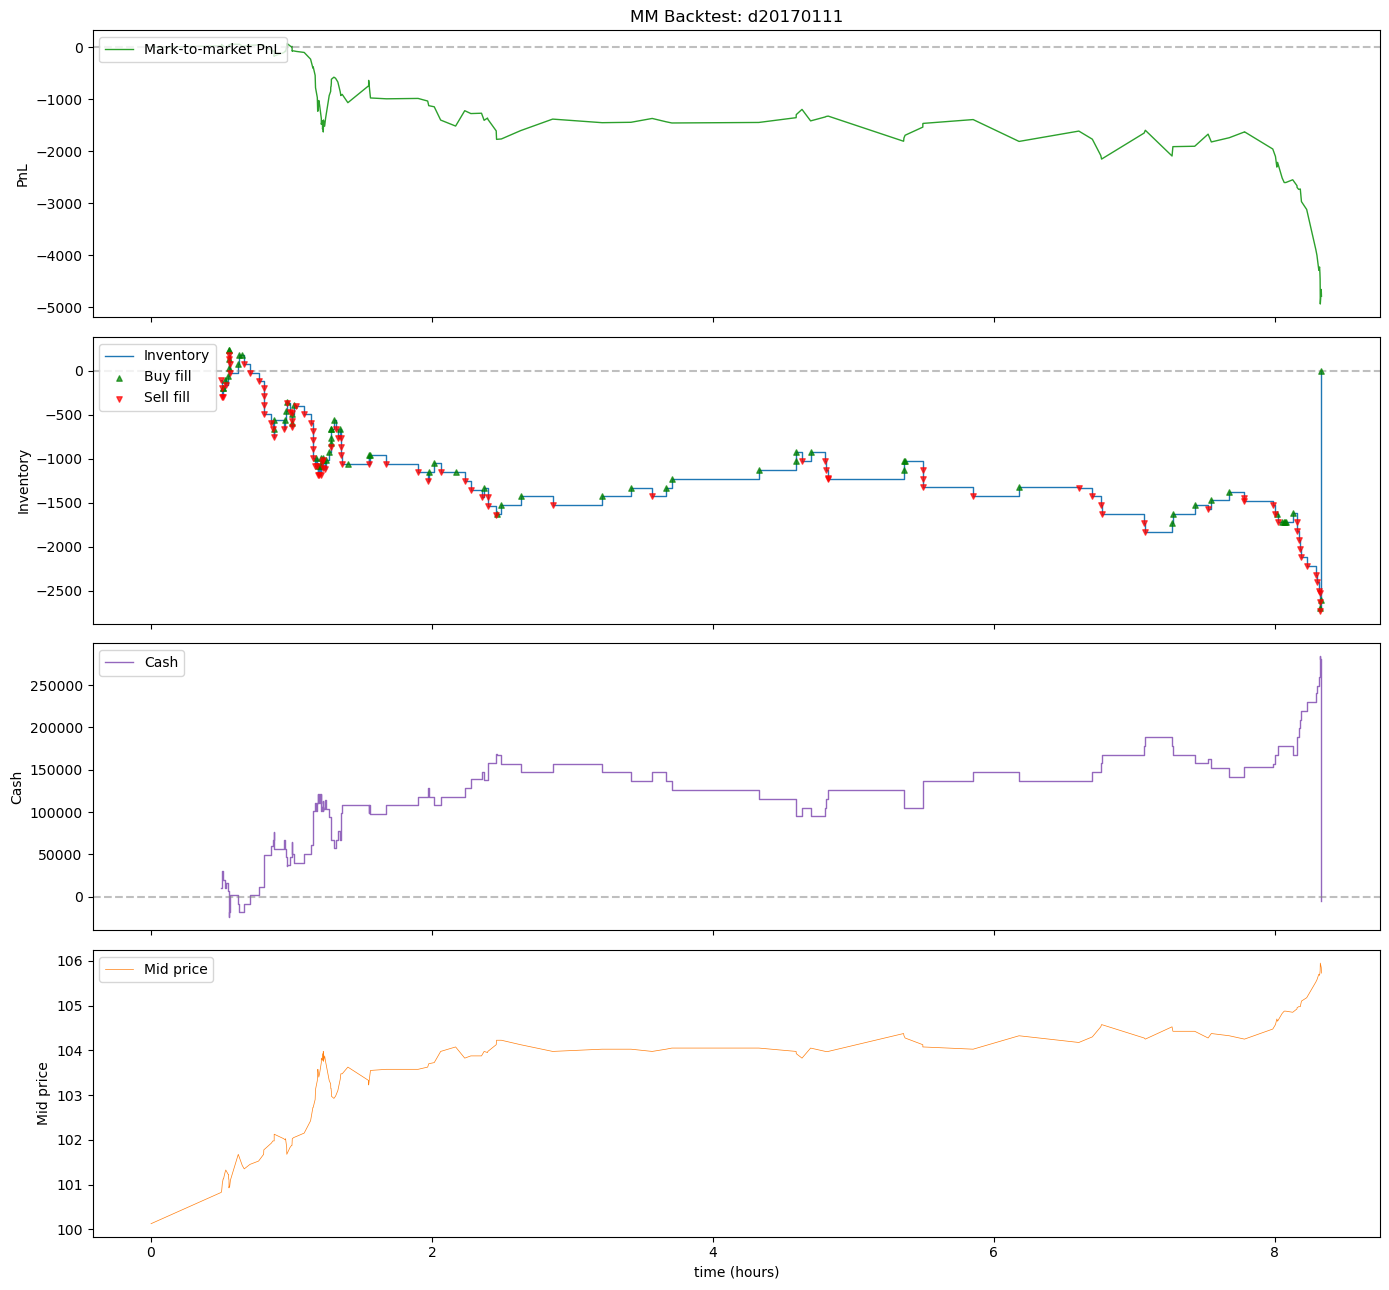

In [ ]:
random.seed(42)

day = windows[0]
agent = SimpleMarketMaker(offset=1, size=100,
                          tick_size=TICK_SIZE)
stats = bt.run_single(day, agent)

print(f"Window: {day}")
print(f"  PnL: {stats['pnl']:+,.2f}")
print(f"  Trades: {stats['n_trades']}")
print(f"  Max |inventory|: {stats['max_inventory']}")
print(f"  Intraday DD: {stats['intraday_dd']:+,.2f}")

bt.plot_single(agent, title=f"MM Backtest: {day}")

## 3. All-Windows Run

Run across every trading day (window) and collect per-window statistics.
Each row in `results_df` is one independent sample.

In [ ]:
results_df = bt.run_all(
    lambda: SimpleMarketMaker(offset=1, size=100,
                              tick_size=TICK_SIZE),
    seed=None, carry_cash=True,
)

print(f"\nProcessed {len(results_df)} windows")
print(results_df[["pnl", "n_trades", "max_inventory", "intraday_dd"]]
      .describe().round(2))

Liquidated -> inventory: 0, cash: -4,783
Liquidated -> inventory: 0, cash: -4,860
Liquidated -> inventory: 0, cash: -3,328
Liquidated -> inventory: 0, cash: -1,582
Liquidated -> inventory: 0, cash: -4,073
Liquidated -> inventory: 0, cash: -14,554
Liquidated -> inventory: 0, cash: -11,299
Liquidated -> inventory: 0, cash: -12,413
Liquidated -> inventory: 0, cash: -11,589
Liquidated -> inventory: 0, cash: -2,417
Liquidated -> inventory: 0, cash: +2,887
Liquidated -> inventory: 0, cash: -675
Liquidated -> inventory: 0, cash: -24,752
Liquidated -> inventory: 0, cash: -33,050
Liquidated -> inventory: 0, cash: -35,662
Liquidated -> inventory: 0, cash: -35,247
Liquidated -> inventory: 0, cash: -35,085
Liquidated -> inventory: 0, cash: -34,683
Liquidated -> inventory: 0, cash: -31,863
Liquidated -> inventory: 0, cash: -31,174
Liquidated -> inventory: 0, cash: -30,986
Liquidated -> inventory: 0, cash: -30,533
Liquidated -> inventory: 0, cash: -27,736
Liquidated -> inventory: 0, cash: -26,730
Li

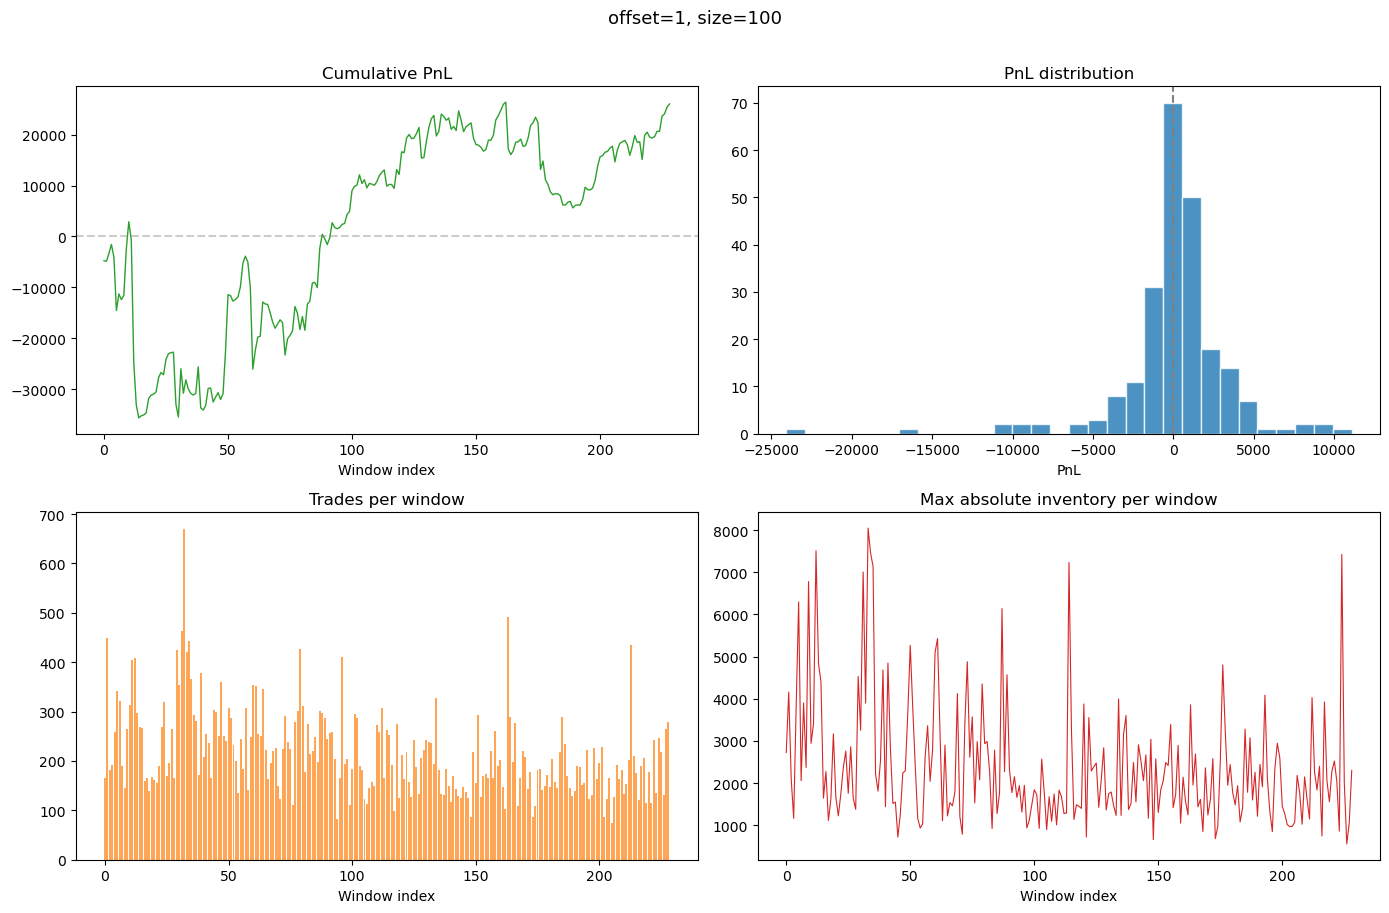

In [ ]:
bt.plot_summary(results_df, title="offset=1, size=100")

### Risk Metrics

In [ ]:
daily_pnl = results_df["pnl"]
cum_pnl = daily_pnl.cumsum()
drawdown = cum_pnl - cum_pnl.cummax()

sharpe = (
    daily_pnl.mean() / daily_pnl.std() * np.sqrt(252)
    if daily_pnl.std() > 0 else 0.0
)

print("=" * 55)
print("RISK METRICS")
print("=" * 55)
print(f"  Total PnL:           {daily_pnl.sum():+,.2f}")
print(f"  Mean daily PnL:      {daily_pnl.mean():+,.2f}")
print(f"  Std daily PnL:       {daily_pnl.std():,.2f}")
print(f"  Sharpe (annualised): {sharpe:+.2f}")
print(f"  Win rate:            {(daily_pnl > 0).mean():.1%}")
print(f"  Max drawdown:        {drawdown.min():+,.2f}")

RISK METRICS
  Total PnL:           +26,030.92
  Mean daily PnL:      +113.67
  Std daily PnL:       3,420.29
  Sharpe (annualised): +0.53
  Win rate:            61.6%
  Max drawdown:        -38,548.90


In [ ]:
ROOT = Path.cwd().resolve().parent
OUTPUT_DIR = ROOT / "data"
DB_PATH = OUTPUT_DIR / "KGHM_order_flow.sqlite"

TICK_SIZE = 0.05

bt = MMBacktester(DB_PATH, tick_size=TICK_SIZE)

windows = bt.list_windows()
print(f"DB type : {bt.db_type}")
print(f"Tick    : {bt.tick_size}")
print(f"Windows : {len(windows)}  ({windows[0]} .. {windows[-1]})")

DB type : empirical
Tick    : 0.05
Windows : 229  (d20170111 .. d20171206)


Liquidated -> inventory: 0, cash: +9,883
Window: d20170112
  PnL: -117.30
  Trades: 33
  Max |inventory|: 92
  Intraday DD: -248.40


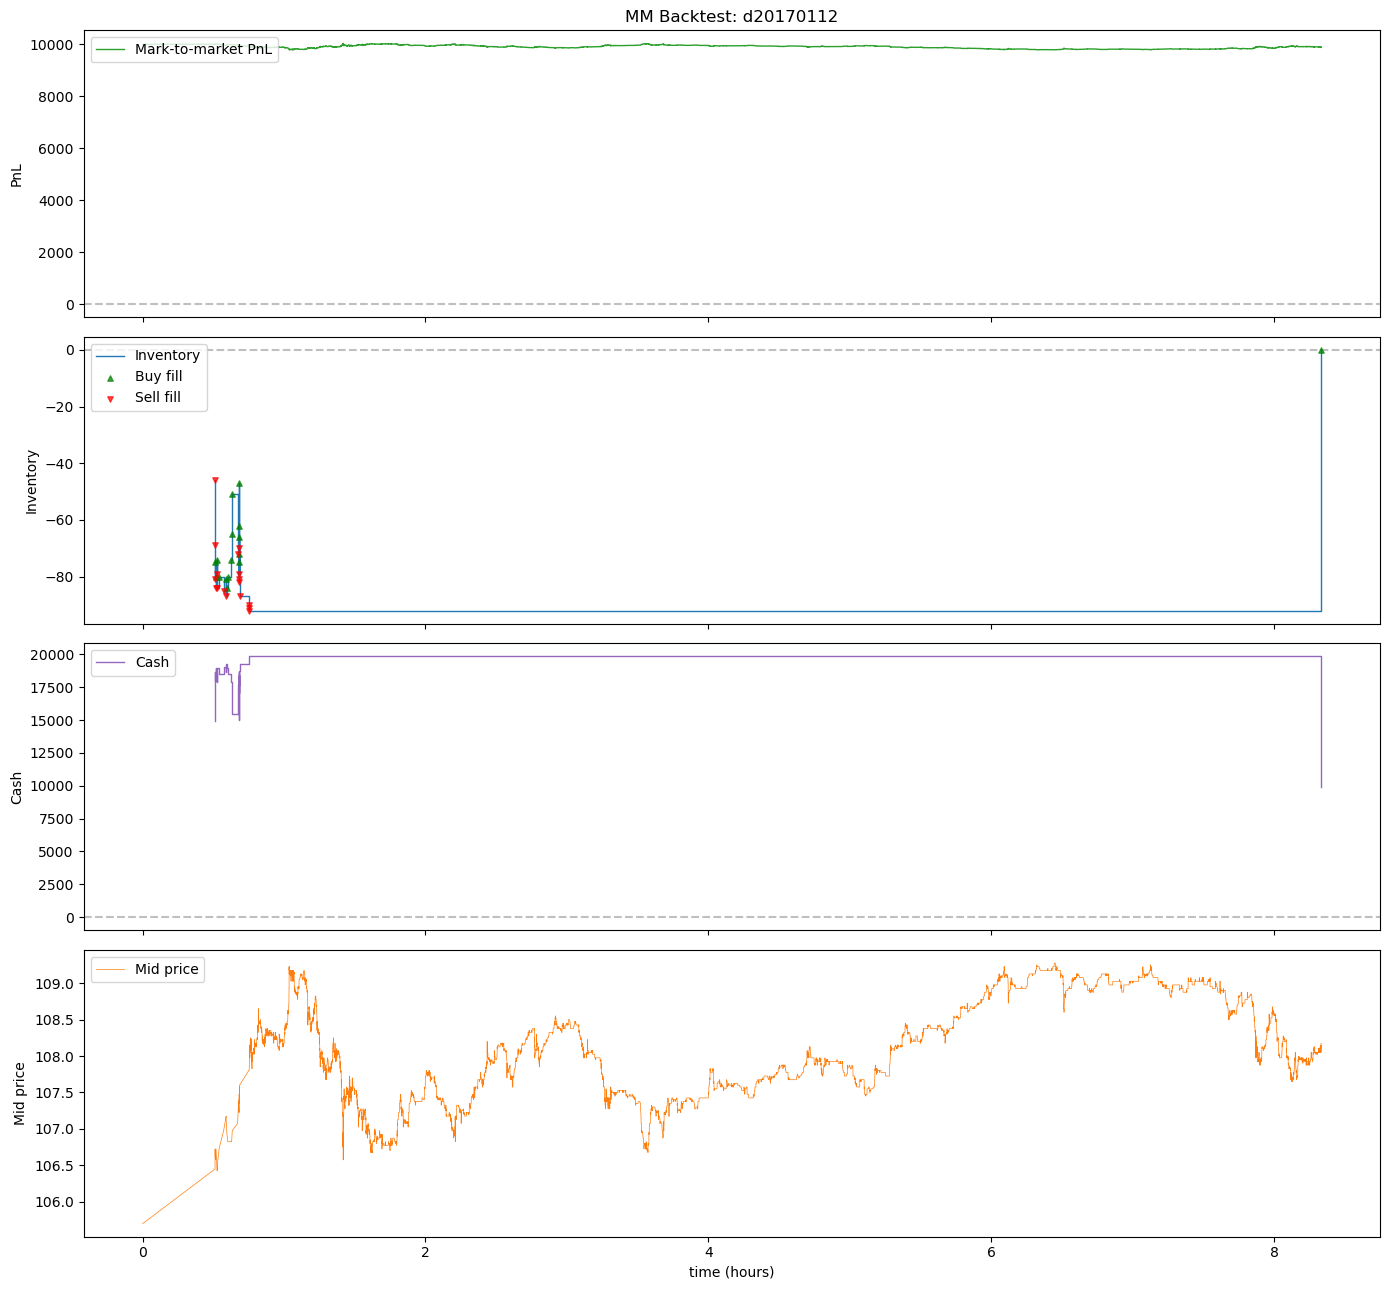

In [ ]:
day = windows[1]
agent = SimpleMarketMaker(offset=1, size=1000,
                          tick_size=TICK_SIZE, initial_cash=10_000, initial_inventory=0)
stats = bt.run_single(day, agent)

print(f"Window: {day}")
print(f"  PnL: {stats['pnl']:+,.2f}")
print(f"  Trades: {stats['n_trades']}")
print(f"  Max |inventory|: {stats['max_inventory']}")
print(f"  Intraday DD: {stats['intraday_dd']:+,.2f}")

bt.plot_single(agent, title=f"MM Backtest: {day}")

In [ ]:
results_df = bt.run_all(
    lambda: SimpleMarketMaker(offset=1, size=1000,
                          tick_size=TICK_SIZE, initial_cash=10_000, initial_inventory=0),
    seed=None, carry_cash=True,
)

print(f"\nProcessed {len(results_df)} windows")
print(results_df[["pnl", "n_trades", "max_inventory", "intraday_dd"]]
      .describe().round(2))

Liquidated -> inventory: 0, cash: +9,544
Liquidated -> inventory: 0, cash: +9,434
Liquidated -> inventory: 0, cash: +9,333
Liquidated -> inventory: 0, cash: +9,300
Liquidated -> inventory: 0, cash: +9,183
Liquidated -> inventory: 0, cash: +8,901
Liquidated -> inventory: 0, cash: +9,032
Liquidated -> inventory: 0, cash: +9,093
Liquidated -> inventory: 0, cash: +9,116
Liquidated -> inventory: 0, cash: +9,069
Liquidated -> inventory: 0, cash: +8,838
Liquidated -> inventory: 0, cash: +8,973
Liquidated -> inventory: 0, cash: +8,117
Liquidated -> inventory: 0, cash: +8,199
Liquidated -> inventory: 0, cash: +8,061
Liquidated -> inventory: 0, cash: +8,001
Liquidated -> inventory: 0, cash: +8,035
Liquidated -> inventory: 0, cash: +8,040
Liquidated -> inventory: 0, cash: +7,949
Liquidated -> inventory: 0, cash: +8,014
Liquidated -> inventory: 0, cash: +8,147
Liquidated -> inventory: 0, cash: +8,214
Liquidated -> inventory: 0, cash: +8,149
Liquidated -> inventory: 0, cash: +8,169
Liquidated -> in

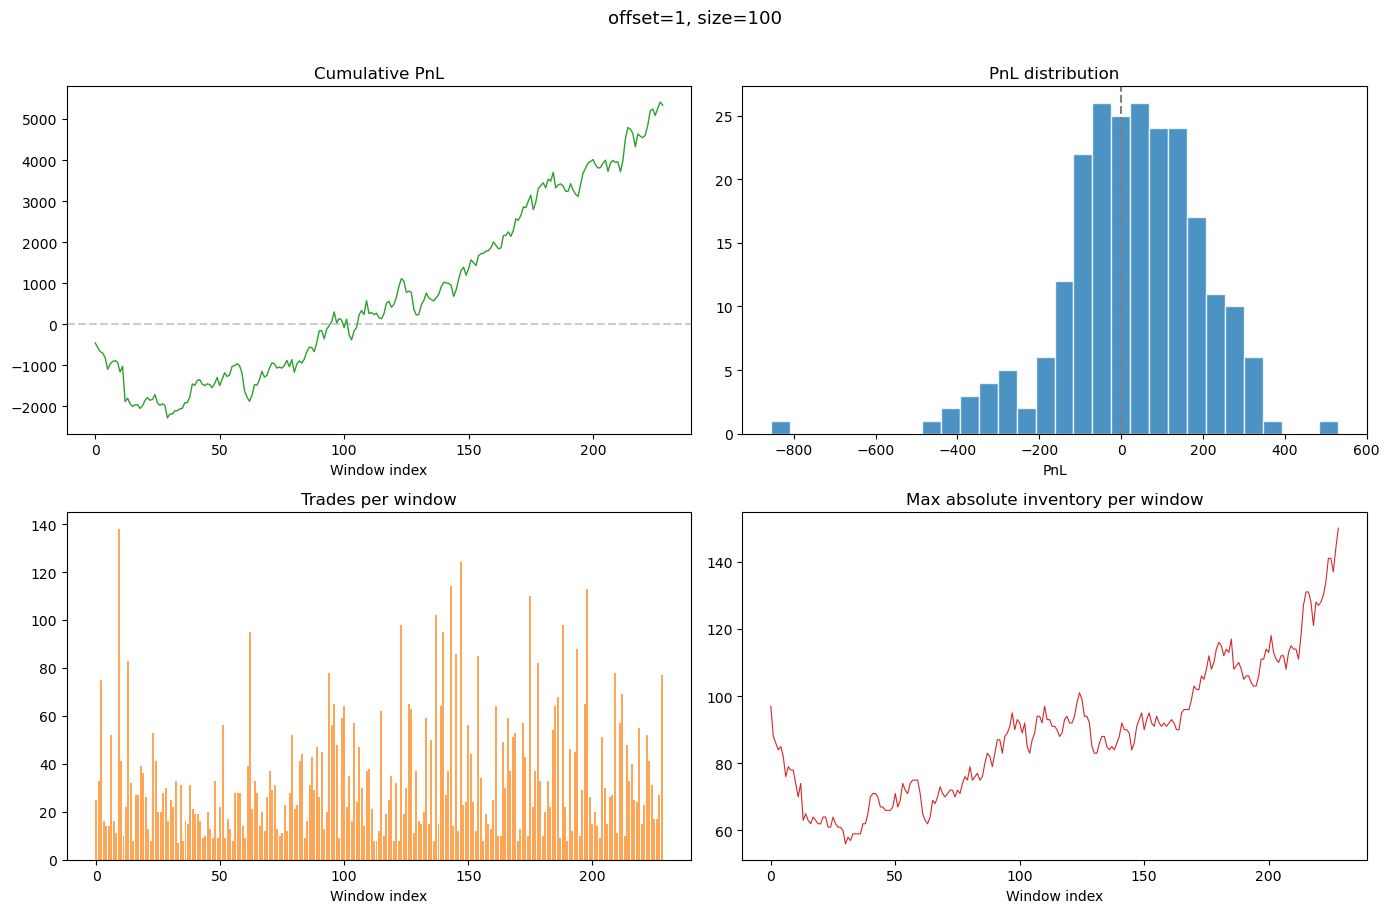

In [ ]:
bt.plot_summary(results_df, title="offset=1, size=100")

In [3]:
ROOT = Path.cwd().resolve().parent
OUTPUT_DIR = ROOT / "data"
DB_PATH = OUTPUT_DIR / "KGHM_order_flow.sqlite"

TICK_SIZE = 0.05

bt = MMBacktester(DB_PATH, tick_size=TICK_SIZE)

windows = bt.list_windows()
print(f"DB type : {bt.db_type}")
print(f"Tick    : {bt.tick_size}")
print(f"Windows : {len(windows)}  ({windows[0]} .. {windows[-1]})")

DB type : empirical
Tick    : 0.05
Windows : 229  (d20170111 .. d20171206)


In [4]:
conn = sqlite3.connect(str(DB_PATH))
mo_df = pd.read_sql("SELECT * FROM mo_orders", conn)
orders_df = pd.read_sql("SELECT best_bid, best_ask FROM orders ORDER BY timestamp", conn)
conn.close()

as_params = AvellanedaStoikovMM.calibrate(mo_df, orders_df, tick_size=TICK_SIZE)
print(as_params)

AvellanedaStoikovMM.calibrate:
  calibrate_k: fitted k = 0.5002  (from 10 levels, 612612 MOs)
  calibrate_vol_halflife: best half-life = 200  (MSE = 3.49e-14, from 5 candidates)
  -> {'k': 0.5002061042965513, 'vol_halflife': 200, 'tick_size': 0.05}
{'k': 0.5002061042965513, 'vol_halflife': 200, 'tick_size': 0.05}


Liquidated -> inventory: 0, cash: +10,120
Window: d20170112
  PnL: +120.10
  Trades: 11
  Max |inventory|: 80
  Intraday DD: -162.23


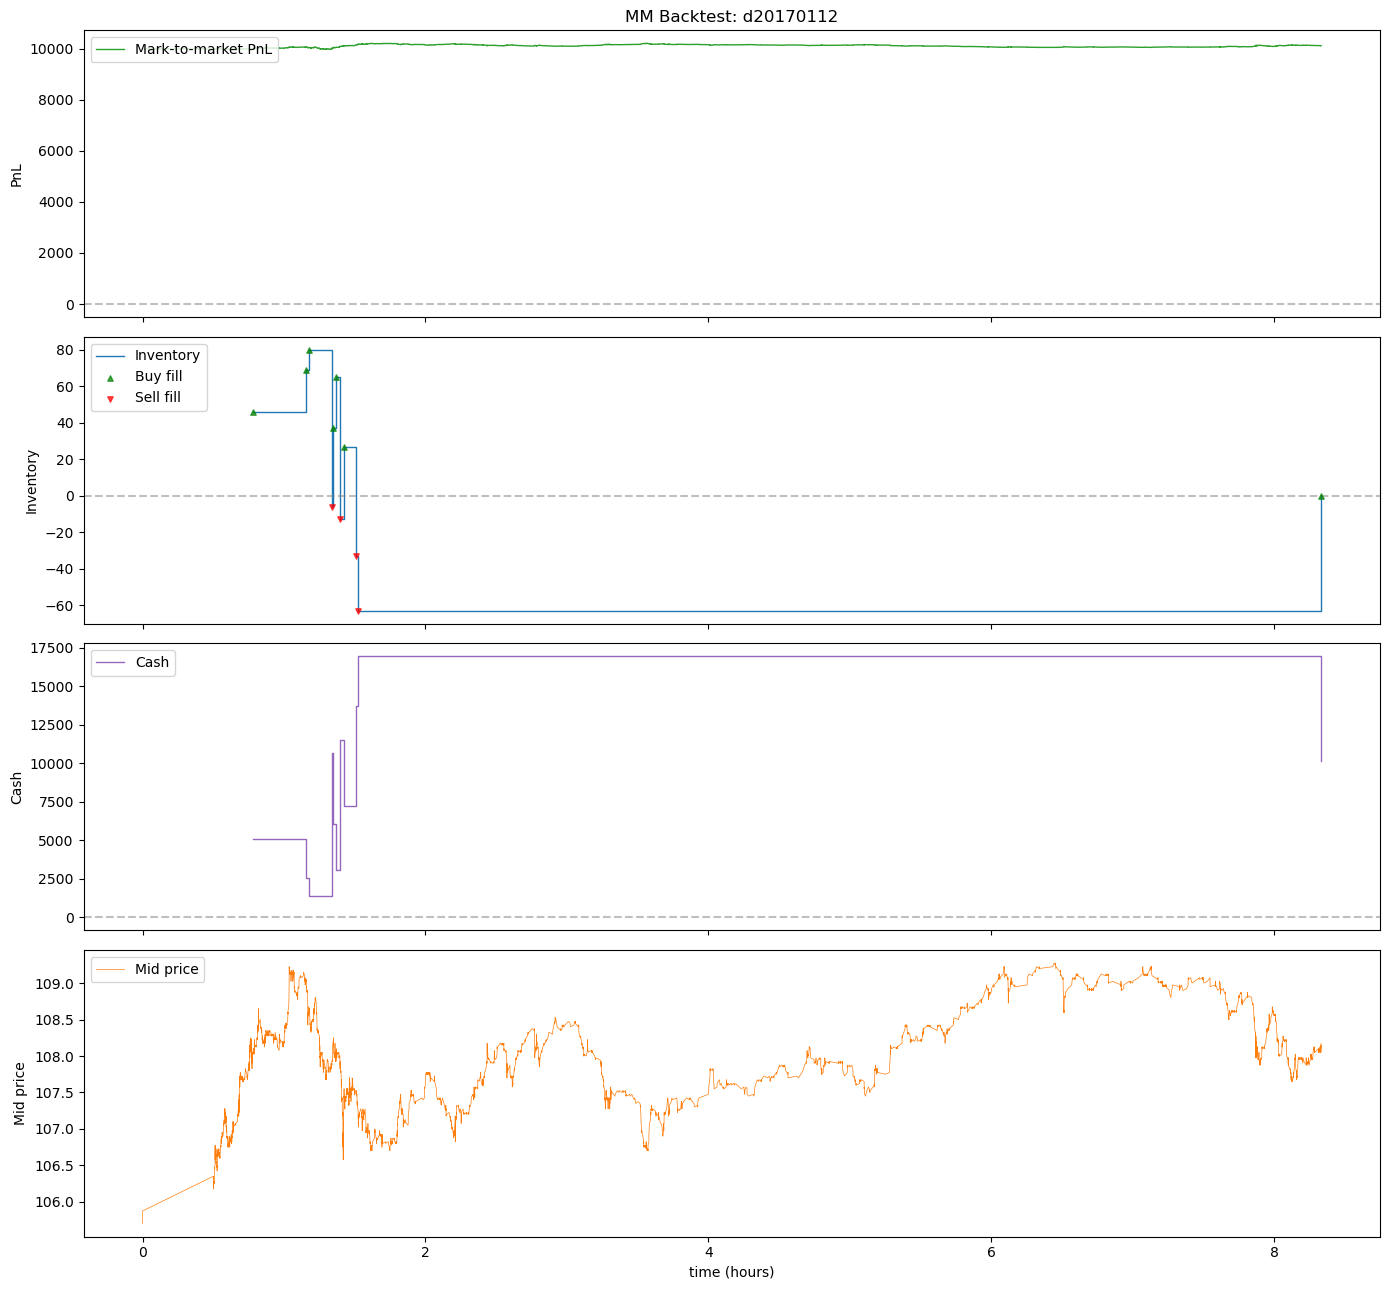

In [5]:
day = windows[1]
agent = AvellanedaStoikovMM(**as_params, gamma=5.0, horizon=5000.0,
                    size=100, initial_cash=10_000, initial_inventory=0)
stats = bt.run_single(day, agent)

print(f"Window: {day}")
print(f"  PnL: {stats['pnl']:+,.2f}")
print(f"  Trades: {stats['n_trades']}")
print(f"  Max |inventory|: {stats['max_inventory']}")
print(f"  Intraday DD: {stats['intraday_dd']:+,.2f}")

bt.plot_single(agent, title=f"MM Backtest: {day}")

In [6]:
results_df = bt.run_all(
    lambda: AvellanedaStoikovMM(**as_params, gamma=5.0, horizon=5000.0,
                    size=100, initial_cash=10_000, initial_inventory=0),
    seed=None, carry_cash=True,
)

print(f"\nProcessed {len(results_df)} windows")
print(results_df[["pnl", "n_trades", "max_inventory", "intraday_dd"]]
      .describe().round(2))

Liquidated -> inventory: 0, cash: +10,057
Liquidated -> inventory: 0, cash: +10,178
Liquidated -> inventory: 0, cash: +10,230
Liquidated -> inventory: 0, cash: +10,194
Liquidated -> inventory: 0, cash: +10,143
Liquidated -> inventory: 0, cash: +9,832
Liquidated -> inventory: 0, cash: +9,946
Liquidated -> inventory: 0, cash: +10,028
Liquidated -> inventory: 0, cash: +10,107
Liquidated -> inventory: 0, cash: +10,035
Liquidated -> inventory: 0, cash: +10,162
Liquidated -> inventory: 0, cash: +10,113
Liquidated -> inventory: 0, cash: +9,029
Liquidated -> inventory: 0, cash: +9,007
Liquidated -> inventory: 0, cash: +8,971
Liquidated -> inventory: 0, cash: +9,027
Liquidated -> inventory: 0, cash: +9,063
Liquidated -> inventory: 0, cash: +9,111
Liquidated -> inventory: 0, cash: +9,176
Liquidated -> inventory: 0, cash: +9,152
Nothing to liquidate (inventory = 0)
Nothing to liquidate (inventory = 0)
Liquidated -> inventory: 0, cash: +9,244
Liquidated -> inventory: 0, cash: +9,278
Liquidated -> 

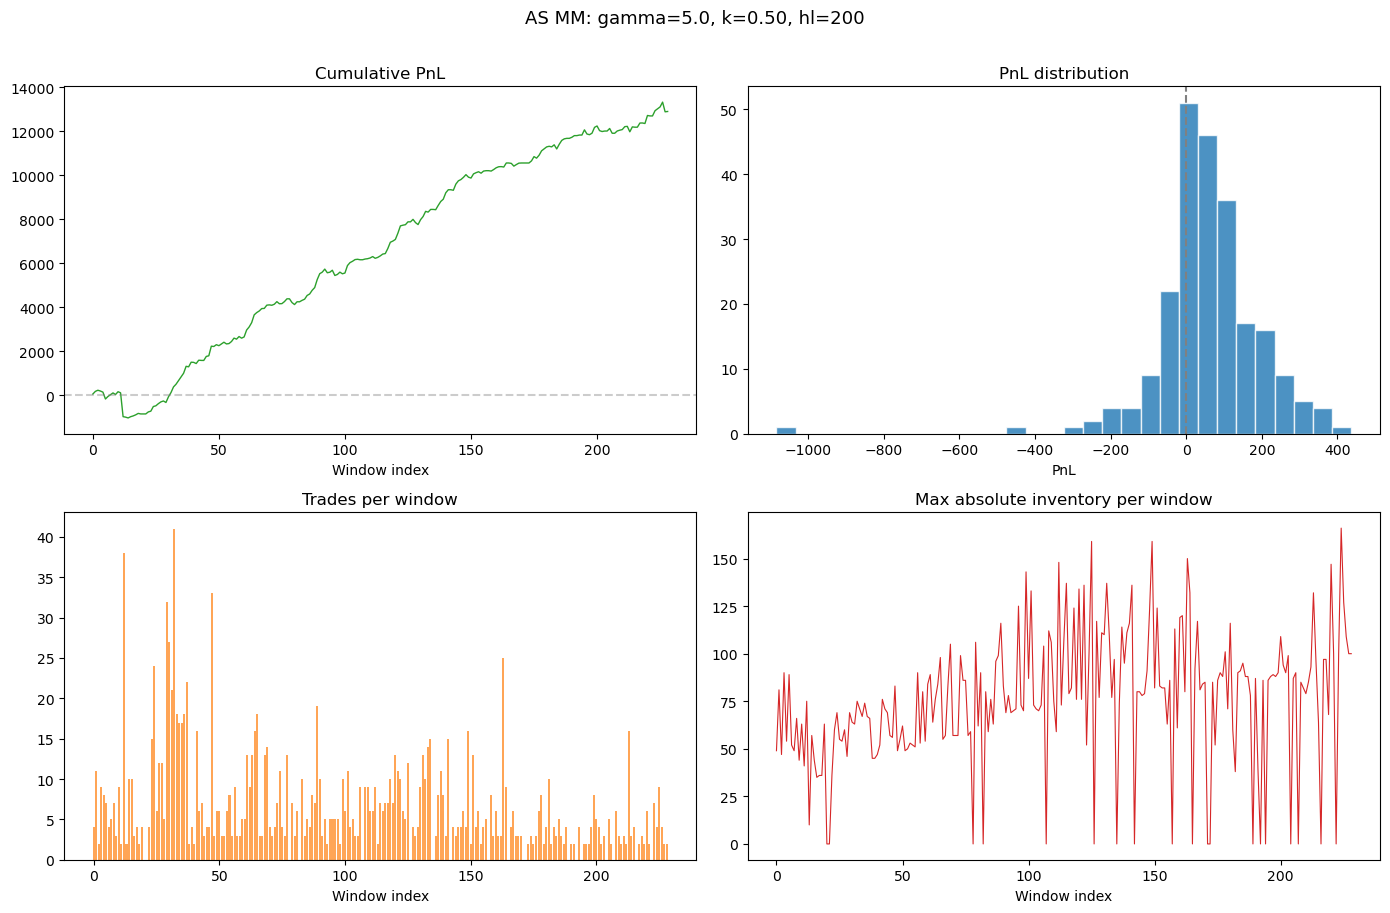

In [7]:
bt.plot_summary(results_df, title=f"AS MM: gamma=5.0, k={as_params['k']:.2f}, hl={as_params['vol_halflife']}") 

---

## 4. Simulated Data Backtest

Run the same three MM strategies on simulated order-flow data
(`sim_events_single_full.sqlite`) for comparison with the empirical results.

In [10]:
SIM_DB = OUTPUT_DIR / "sim_events_single_full.sqlite"
SIM_TICK = 0.05
WINDOW_SIZE = 50_000

bt_sim = MMBacktester(SIM_DB, tick_size=SIM_TICK)

sim_windows = bt_sim.list_windows(window_size=WINDOW_SIZE)
print(f"DB type : {bt_sim.db_type}")
print(f"Tick    : {bt_sim.tick_size}")
print(f"Windows : {len(sim_windows)}")

DB type : simulated
Tick    : 0.05
Windows : 358


### 4a. Simple MM (unlimited cash) on sim data

In [11]:
sim_results_simple = bt_sim.run_all(
    lambda: SimpleMarketMaker(offset=1, size=100, tick_size=SIM_TICK),
    seed=None, window_size=WINDOW_SIZE,
)

print(f"\nProcessed {len(sim_results_simple)} windows")
print(sim_results_simple[["pnl", "n_trades", "max_inventory", "intraday_dd"]]
      .describe().round(2))

Liquidated -> inventory: 0, cash: -40
Liquidated -> inventory: 0, cash: -440
Liquidated -> inventory: 0, cash: -2,101
Liquidated -> inventory: 0, cash: -330
Liquidated -> inventory: 0, cash: -216
Liquidated -> inventory: 0, cash: -3,576
Liquidated -> inventory: 0, cash: -748
Liquidated -> inventory: 0, cash: -949
Liquidated -> inventory: 0, cash: +400
Liquidated -> inventory: 0, cash: -15
Liquidated -> inventory: 0, cash: +566
Liquidated -> inventory: 0, cash: -1,118
Liquidated -> inventory: 0, cash: -545
Liquidated -> inventory: 0, cash: -2,405
Liquidated -> inventory: 0, cash: +800
Liquidated -> inventory: 0, cash: -1,950
Liquidated -> inventory: 0, cash: +1,148
Liquidated -> inventory: 0, cash: +525
Liquidated -> inventory: 0, cash: +701
Liquidated -> inventory: 0, cash: +49
Liquidated -> inventory: 0, cash: +260
Liquidated -> inventory: 0, cash: +265
Liquidated -> inventory: 0, cash: +81
Liquidated -> inventory: 0, cash: +990
Liquidated -> inventory: 0, cash: -1,715
Liquidated -> i

KeyboardInterrupt: 

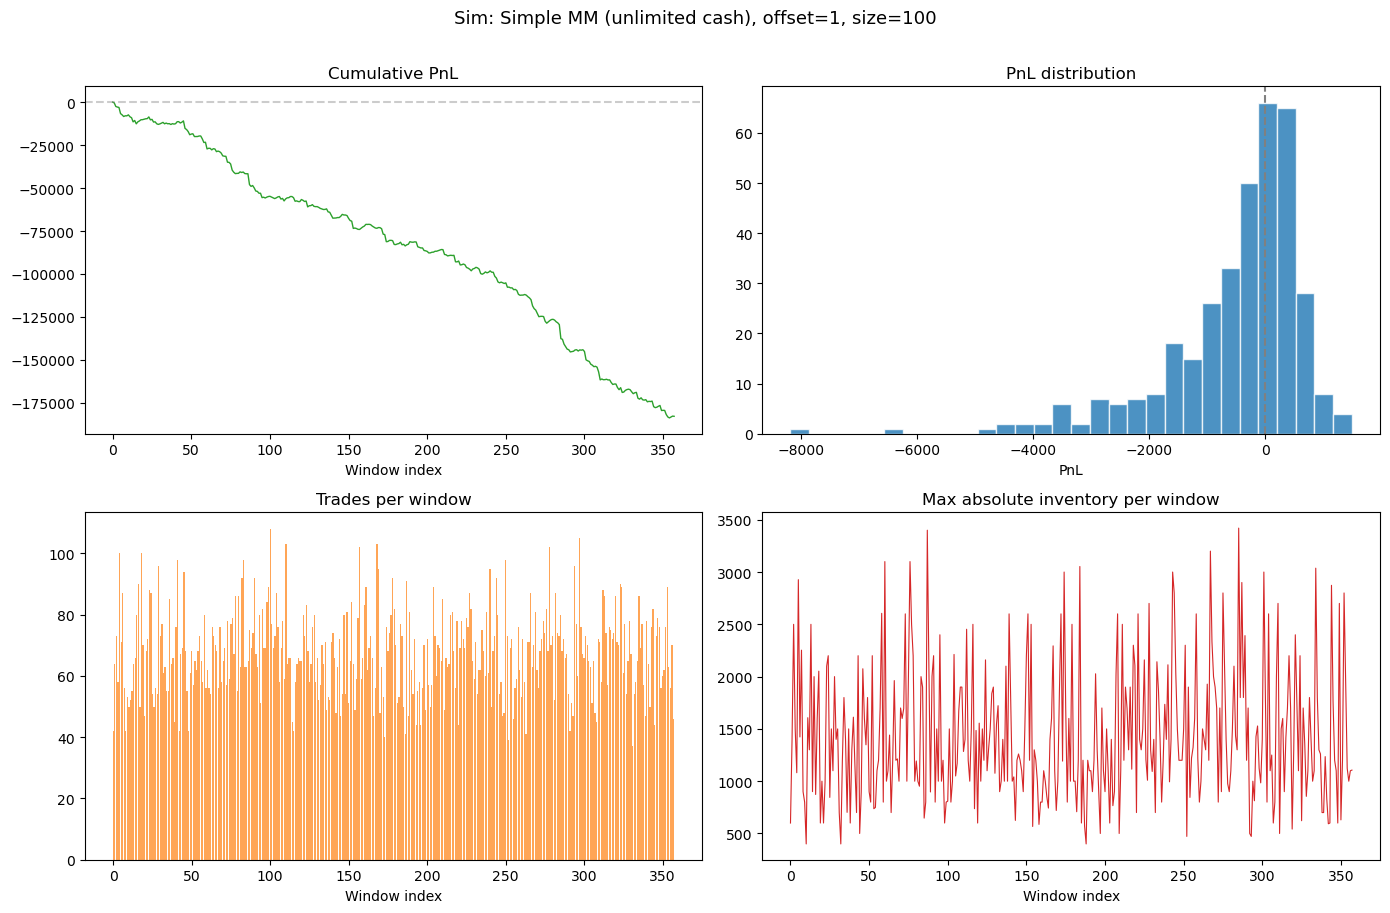

In [ ]:
bt_sim.plot_summary(sim_results_simple, title="Sim: Simple MM (unlimited cash), offset=1, size=100")

### 4b. Simple MM (constrained cash) on sim data

In [ ]:
sim_results_simple_cash = bt_sim.run_all(
    lambda: SimpleMarketMaker(offset=1, size=1000, tick_size=SIM_TICK,
                              initial_cash=10_000, initial_inventory=0),
    seed=None, carry_cash=True, window_size=WINDOW_SIZE,
)

print(f"\nProcessed {len(sim_results_simple_cash)} windows")
print(sim_results_simple_cash[["pnl", "n_trades", "max_inventory", "intraday_dd"]]
      .describe().round(2))

Liquidated -> inventory: 0, cash: +9,974
Liquidated -> inventory: 0, cash: +9,901
Liquidated -> inventory: 0, cash: +9,764
Liquidated -> inventory: 0, cash: +9,654
Liquidated -> inventory: 0, cash: +9,772
Liquidated -> inventory: 0, cash: +9,846
Liquidated -> inventory: 0, cash: +10,025
Liquidated -> inventory: 0, cash: +10,053
Liquidated -> inventory: 0, cash: +10,038
Liquidated -> inventory: 0, cash: +9,933
Liquidated -> inventory: 0, cash: +9,852
Liquidated -> inventory: 0, cash: +9,731
Liquidated -> inventory: 0, cash: +9,814
Liquidated -> inventory: 0, cash: +9,936
Liquidated -> inventory: 0, cash: +10,010
Liquidated -> inventory: 0, cash: +10,091
Liquidated -> inventory: 0, cash: +10,164
Liquidated -> inventory: 0, cash: +10,174
Liquidated -> inventory: 0, cash: +10,183
Liquidated -> inventory: 0, cash: +10,131
Liquidated -> inventory: 0, cash: +10,140
Liquidated -> inventory: 0, cash: +10,203
Liquidated -> inventory: 0, cash: +10,145
Liquidated -> inventory: 0, cash: +10,210
Liq

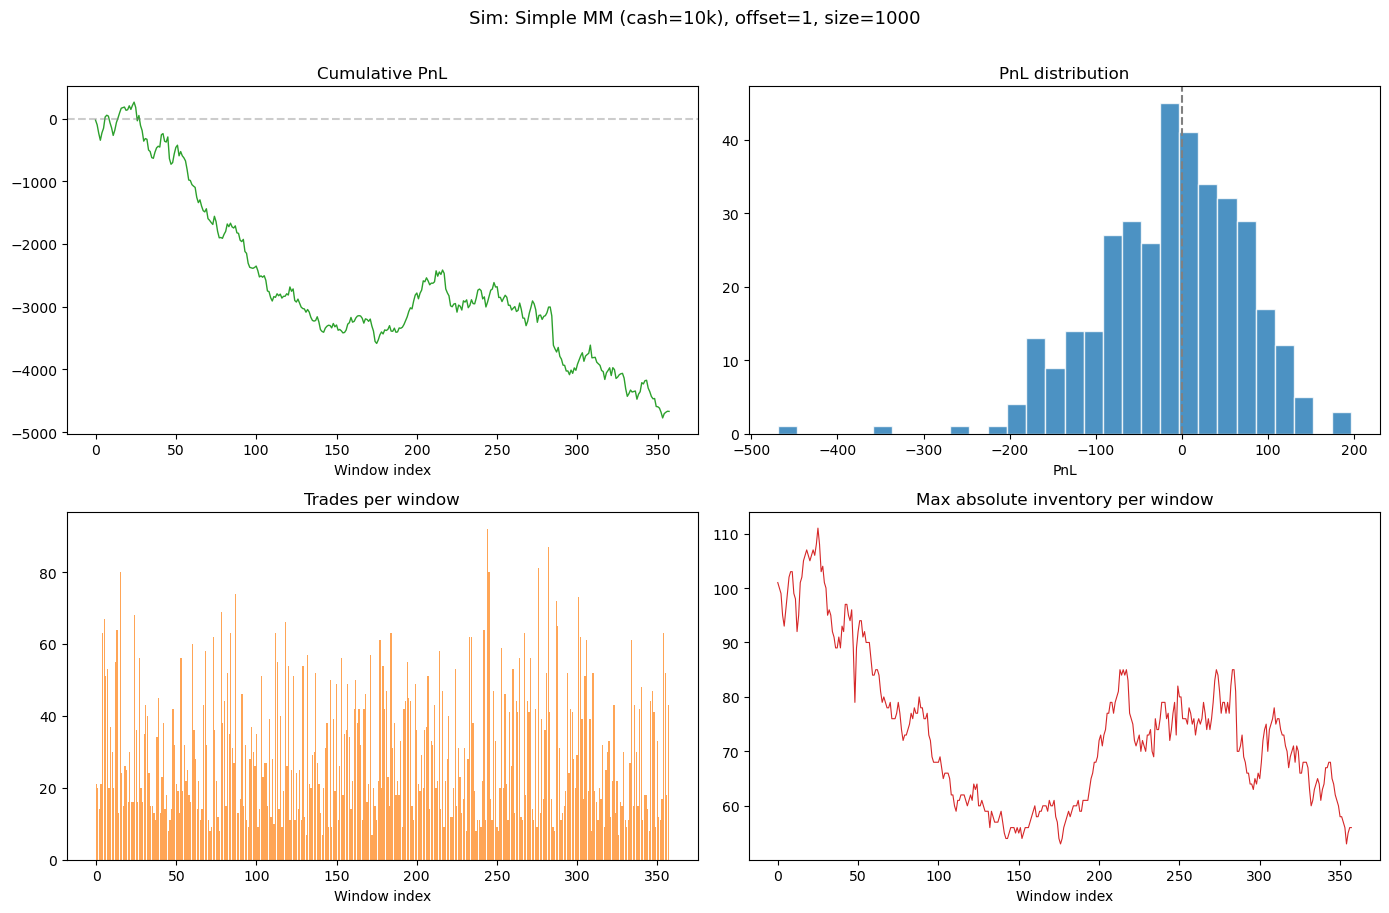

In [ ]:
bt_sim.plot_summary(sim_results_simple_cash, title="Sim: Simple MM (cash=10k), offset=1, size=1000")

### 4c. Avellaneda-Stoikov MM (calibrated) on sim data

In [ ]:
conn = sqlite3.connect(str(SIM_DB))
sim_mo_df = pd.read_sql("SELECT * FROM mo_orders", conn)
sim_orders_df = pd.read_sql("SELECT best_bid, best_ask FROM orders ORDER BY timestamp", conn)
conn.close()

as_params_sim = AvellanedaStoikovMM.calibrate(sim_mo_df, sim_orders_df, tick_size=SIM_TICK)
print(as_params_sim)

AvellanedaStoikovMM.calibrate:
  calibrate_k: fitted k = 0.8048  (from 10 levels, 552749 MOs)
  calibrate_vol_halflife: best half-life = 200  (MSE = 8.76e-18, from 5 candidates)
  -> {'k': 0.8048008239005097, 'vol_halflife': 200, 'tick_size': 0.05}
{'k': 0.8048008239005097, 'vol_halflife': 200, 'tick_size': 0.05}


In [ ]:
sim_results_as = bt_sim.run_all(
    lambda: AvellanedaStoikovMM(**as_params_sim, gamma=2.0, horizon=5000.0,
                                size=100, initial_cash=10_000, initial_inventory=0),
    seed=None, carry_cash=True, window_size=WINDOW_SIZE,
)

print(f"\nProcessed {len(sim_results_as)} windows")
print(sim_results_as[["pnl", "n_trades", "max_inventory", "intraday_dd"]]
      .describe().round(2))

Nothing to liquidate (inventory = 0)
Nothing to liquidate (inventory = 0)
Nothing to liquidate (inventory = 0)
Nothing to liquidate (inventory = 0)
Nothing to liquidate (inventory = 0)
Nothing to liquidate (inventory = 0)
Nothing to liquidate (inventory = 0)
Nothing to liquidate (inventory = 0)
Nothing to liquidate (inventory = 0)
Nothing to liquidate (inventory = 0)
Nothing to liquidate (inventory = 0)
Nothing to liquidate (inventory = 0)
Nothing to liquidate (inventory = 0)
Nothing to liquidate (inventory = 0)
Nothing to liquidate (inventory = 0)
Nothing to liquidate (inventory = 0)
Nothing to liquidate (inventory = 0)
Nothing to liquidate (inventory = 0)
Nothing to liquidate (inventory = 0)
Nothing to liquidate (inventory = 0)
Nothing to liquidate (inventory = 0)
Nothing to liquidate (inventory = 0)
Nothing to liquidate (inventory = 0)
Nothing to liquidate (inventory = 0)
Nothing to liquidate (inventory = 0)
Nothing to liquidate (inventory = 0)
Nothing to liquidate (inventory = 0)
N

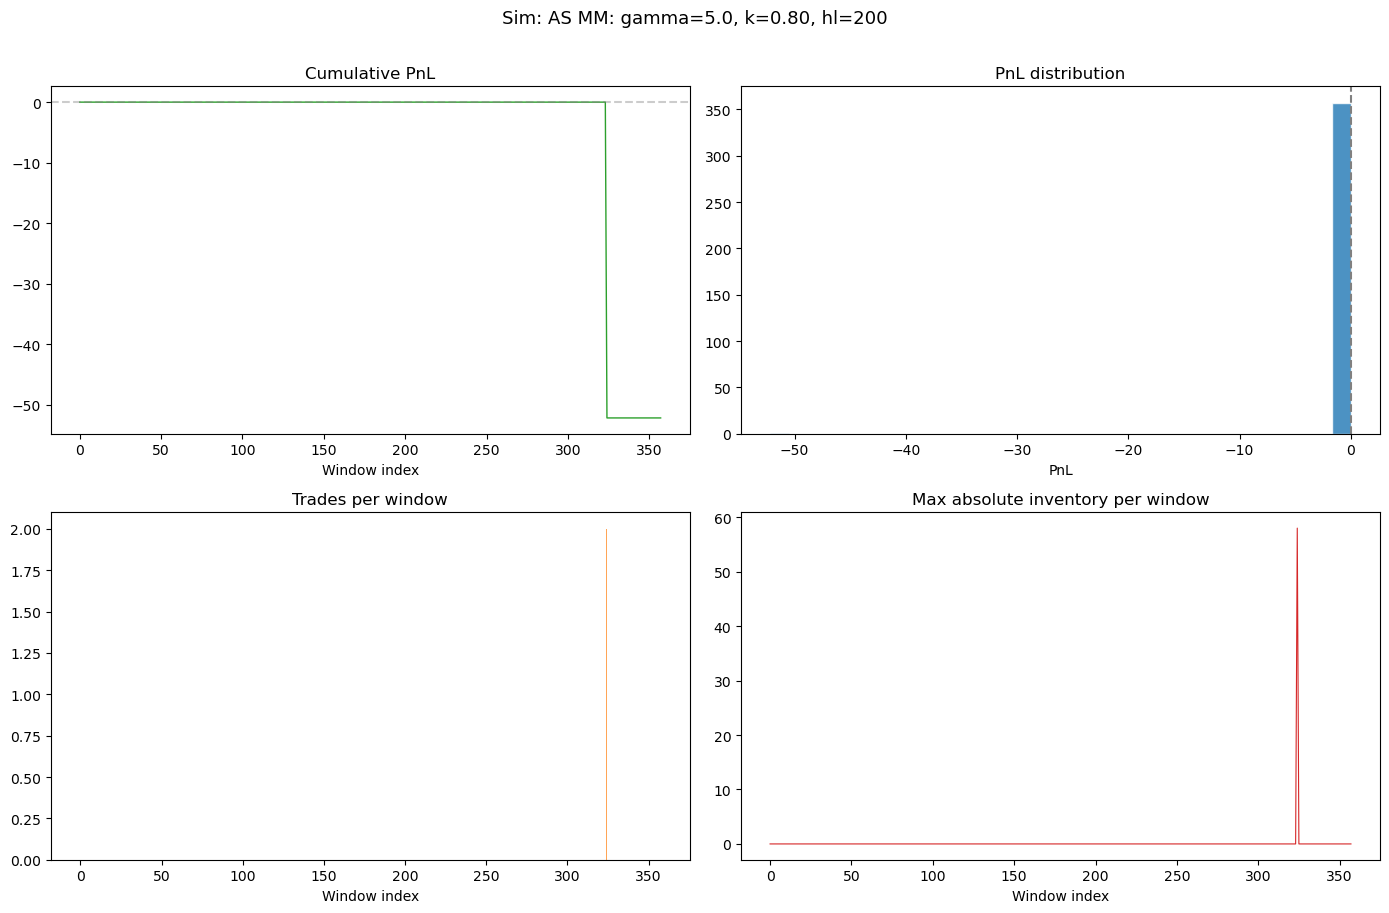

In [ ]:
bt_sim.plot_summary(sim_results_as,
                    title=f"Sim: AS MM: gamma=5.0, k={as_params_sim['k']:.2f}, hl={as_params_sim['vol_halflife']}")